In [ ]:
import joblib
model=joblib.load("tic (1).pkl")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
name = [' top-left-square', 'top-middle-square', 'top-right-square',
       'middle-left-square', 'middle-middle-square', 'middle-right-square',
       'bottom-left-square', 'bottom-middle-square', 'bottom-right-square']

In [ ]:
df=pd.read_csv("test _tic.csv" )

In [ ]:

df=pd.DataFrame(df)
df

,top-left,top-middle,top-right,middle-left,middle-middle,middle-right,bottom-left,bottom-middle,bottom-right
0,x,x,x,o,o,b,o,b,b
1,o,o,o,x,x,b,x,b,b
2,x,o,x,o,x,o,b,b,x
3,x,x,o,o,o,x,b,x,b
4,x,b,o,b,x,b,o,b,x
...,...,...,...,...,...,...,...,...,...
105,x,o,x,o,x,o,x,o,x
106,b,o,o,b,x,o,x,x,x
107,o,x,o,x,o,x,o,x,o
108,b,o,o,b,o,x,x,x,x


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110 entries, 0 to 109
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   top-left       110 non-null    object
 1   top-middle     110 non-null    object
 2   top-right      110 non-null    object
 3   middle-left    110 non-null    object
 4   middle-middle  110 non-null    object
 5   middle-right   110 non-null    object
 6   bottom-left    110 non-null    object
 7   bottom-middle  110 non-null    object
 8   bottom-right   110 non-null    object
dtypes: object(9)
memory usage: 7.9+ KB


In [ ]:
mapping = {'x': 1, 'o': -1, 'b': 0}
df = df.replace(mapping)#encoding
df

/tmp/ipython-input-2554798327.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace(mapping)#encoding


,top-left,top-middle,top-right,middle-left,middle-middle,middle-right,bottom-left,bottom-middle,bottom-right
0,1,1,1,-1,-1,0,-1,0,0
1,-1,-1,-1,1,1,0,1,0,0
2,1,-1,1,-1,1,-1,0,0,1
3,1,1,-1,-1,-1,1,0,1,0
4,1,0,-1,0,1,0,-1,0,1
...,...,...,...,...,...,...,...,...,...
105,1,-1,1,-1,1,-1,1,-1,1
106,0,-1,-1,0,1,-1,1,1,1
107,-1,1,-1,1,-1,1,-1,1,-1
108,0,-1,-1,0,-1,1,1,1,1


In [ ]:
df.columns = name

In [ ]:
predictions=model.predict(df)#predict for class
target_names = ['negative' , 'positive']
predicted_classes = [target_names[i] for i in predictions]#for loop to take 2 labels amoung prediction model
df["prediction"] = predicted_classes

In [ ]:
reverse_mapping = {v: k for k, v in mapping.items()}#to bring back the
df = df.replace(reverse_mapping)

In [ ]:
df.head(5)

,top-left-square,top-middle-square,top-right-square,middle-left-square,middle-middle-square,middle-right-square,bottom-left-square,bottom-middle-square,bottom-right-square,prediction
0,x,x,x,o,o,b,o,b,b,positive
1,o,o,o,x,x,b,x,b,b,negative
2,x,o,x,o,x,o,b,b,x,positive
3,x,x,o,o,o,x,b,x,b,negative
4,x,b,o,b,x,b,o,b,x,positive


/tmp/ipython-input-2443888932.py:9: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_encoded = df_for_prediction.replace(mapping).infer_objects(copy=False)


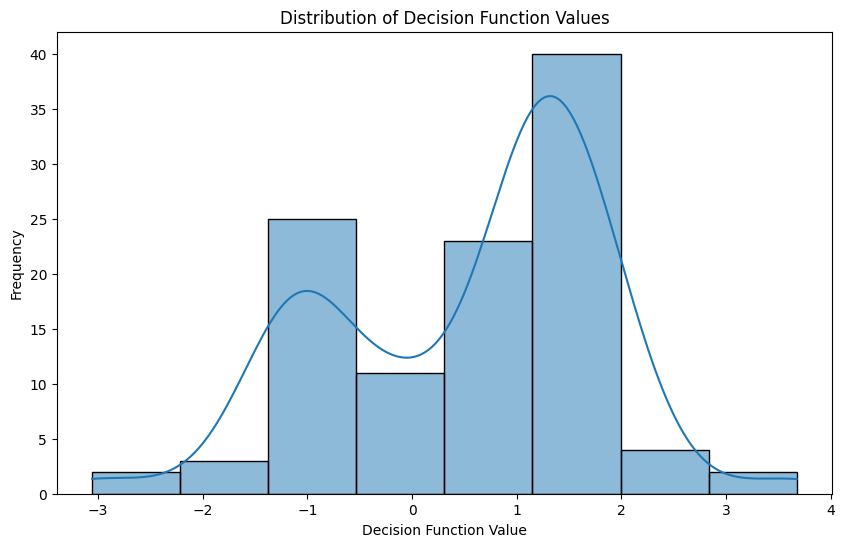

In [ ]:
df_for_prediction = df.drop(columns=['prediction'])
df_encoded = df_for_prediction.replace(mapping).infer_objects(copy=False)
decision_values = model.decision_function(df_encoded)
plt.figure(figsize=(10, 6))
sns.histplot(decision_values, kde=True)
#the plot is taking about the Confidence of the model predictions
#the positive values is predicted positive class
#the negative values is predicted negative class
#the values near to 0 is the confidence (0 is the lowest level )
plt.title('Distribution of Decision Function Values')
plt.xlabel('Decision Function Value')
plt.ylabel('Frequency')
plt.show()